# Dimensionality Reduction & Unsupervised Clustering

## Objective

This notebook applies Principal Component Analysis (PCA) and unsupervised clustering techniques to high-dimensional smartphone sensor data.

The analysis includes:

- Data preprocessing and standardization
- Principal Component Analysis (PCA)
- Explained variance and scree plot analysis
- K-Means clustering
- Elbow Method
- Silhouette Score analysis
- DBSCAN clustering
- Hierarchical clustering
- 2D and 3D cluster visualization
- Comparison of clustering approaches

## Dataset

Human Activity Recognition Using Smartphones

Source: UCI Machine Learning Repository

The dataset contains 10,299 observations and 561 numerical features.

The activity labels are not used as input to the unsupervised clustering algorithms. They may be used later for post-hoc interpretation of the discovered clusters.

In [8]:
from pathlib import Path
import pandas as pd

# Define dataset path
DATA_DIR = Path("../data/raw/UCI HAR Dataset")

# Load feature names
features = pd.read_csv(
    DATA_DIR / "features.txt",
    sep=r"\s+",
    header=None,
    names=["index", "feature"]
)

# Load activity labels
activity_labels = pd.read_csv(
    DATA_DIR / "activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["activity_id", "activity"]
)

# Load training and testing feature data
X_train = pd.read_csv(
    DATA_DIR / "train" / "X_train.txt",
    sep=r"\s+",
    header=None
)

X_test = pd.read_csv(
    DATA_DIR / "test" / "X_test.txt",
    sep=r"\s+",
    header=None
)

# Assign feature names
X_train.columns = features["feature"]
X_test.columns = features["feature"]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Number of features:", len(features))
print("\nActivity labels:")
print(activity_labels)

Training data shape: (7352, 561)
Testing data shape: (2947, 561)
Number of features: 561

Activity labels:
   activity_id            activity
0            1             WALKING
1            2    WALKING_UPSTAIRS
2            3  WALKING_DOWNSTAIRS
3            4             SITTING
4            5            STANDING
5            6              LAYING


In [9]:
# Basic data quality inspection

print("Missing values in training data:", X_train.isna().sum().sum())
print("Missing values in testing data:", X_test.isna().sum().sum())

print("\nFirst 5 feature names:")
print(features["feature"].head())

print("\nFirst 5 rows of training data:")
display(X_train.head())

Missing values in training data: 0
Missing values in testing data: 0

First 5 feature names:
0    tBodyAcc-mean()-X
1    tBodyAcc-mean()-Y
2    tBodyAcc-mean()-Z
3     tBodyAcc-std()-X
4     tBodyAcc-std()-Y
Name: feature, dtype: str

First 5 rows of training data:


feature,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [10]:
# Data quality and consistency checks

print("=== DATA QUALITY CHECKS ===")

# 1. Shape consistency
print("\n1. Shape consistency")
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Feature count matches:", X_train.shape[1] == X_test.shape[1])

# 2. Missing values
print("\n2. Missing values")
print("Training:", X_train.isna().sum().sum())
print("Testing:", X_test.isna().sum().sum())

# 3. Duplicate feature names
print("\n3. Duplicate feature names")
print("Duplicate feature names:", features["feature"].duplicated().sum())

# 4. Data types
print("\n4. Data types")
print("Non-numeric training columns:",
      X_train.select_dtypes(exclude="number").shape[1])

# 5. Constant features
print("\n5. Constant features")
constant_features = X_train.columns[X_train.nunique() <= 1]
print("Number of constant features:", len(constant_features))

# 6. Feature name consistency
print("\n6. Feature name consistency")
print("Train/Test column names match:",
      X_train.columns.equals(X_test.columns))

# Final validation
assert X_train.shape[1] == 561
assert X_test.shape[1] == 561
assert X_train.columns.equals(X_test.columns)
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("\n✓ All core validation checks passed.")

=== DATA QUALITY CHECKS ===

1. Shape consistency
Training features: (7352, 561)
Testing features: (2947, 561)
Feature count matches: True

2. Missing values
Training: 0
Testing: 0

3. Duplicate feature names
Duplicate feature names: 84

4. Data types
Non-numeric training columns: 0

5. Constant features
Number of constant features: 0

6. Feature name consistency
Train/Test column names match: True

✓ All core validation checks passed.


In [12]:
# Make feature names unique while preserving all 561 features
original_feature_names = features["feature"].tolist()

unique_feature_names = pd.Series(original_feature_names).astype(str)

# Add suffixes to duplicated names
seen = {}
final_feature_names = []

for name in unique_feature_names:
    if name not in seen:
        seen[name] = 0
        final_feature_names.append(name)
    else:
        seen[name] += 1
        final_feature_names.append(f"{name}__dup{seen[name]}")

X_train.columns = final_feature_names
X_test.columns = final_feature_names

print("Original feature count:", len(original_feature_names))
print("Final feature count:", len(final_feature_names))
print("Duplicate column names after renaming:",
      X_train.columns.duplicated().sum())

Original feature count: 561
Final feature count: 561
Duplicate column names after renaming: 0


In [13]:
from sklearn.preprocessing import StandardScaler

# Standardize using training data only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

print("\nTraining mean (approx.):", X_train_scaled.mean())
print("Training standard deviation (approx.):", X_train_scaled.std())

Training scaled shape: (7352, 561)
Testing scaled shape: (2947, 561)

Training mean (approx.): 1.1804271735699034e-17
Training standard deviation (approx.): 1.0


In [14]:
from sklearn.decomposition import PCA

# Fit PCA on the standardized training data
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of principal components:", X_train_pca.shape[1])
print("PCA output shape:", X_train_pca.shape)

Original number of features: 561
Number of principal components: 561
PCA output shape: (7352, 561)


In [16]:
# Inspect explained variance

explained_variance = pca.explained_variance_ratio_

print("Total explained variance:", explained_variance.sum())
print("First 10 components:")
print(explained_variance[:10])

Total explained variance: 0.9999999999999997
First 10 components:
[0.50781172 0.0658068  0.02806437 0.02503953 0.01888285 0.01724006
 0.01371011 0.01199078 0.0099586  0.00965087]


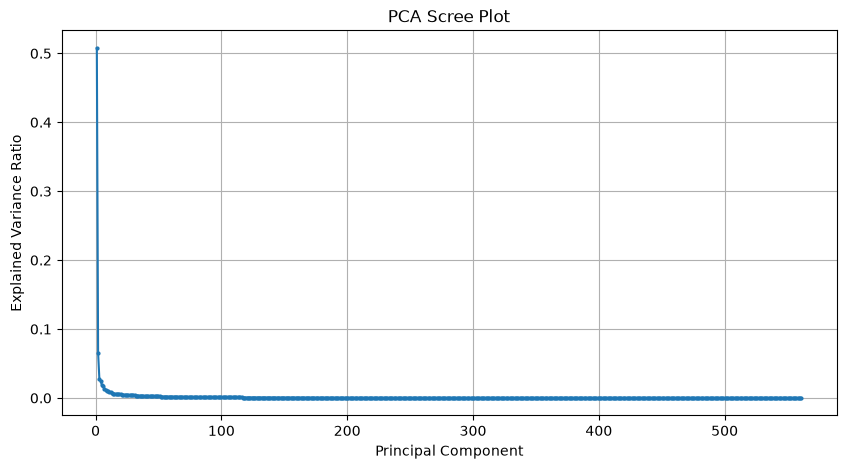

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance ratio
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o",
    markersize=2
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.show()

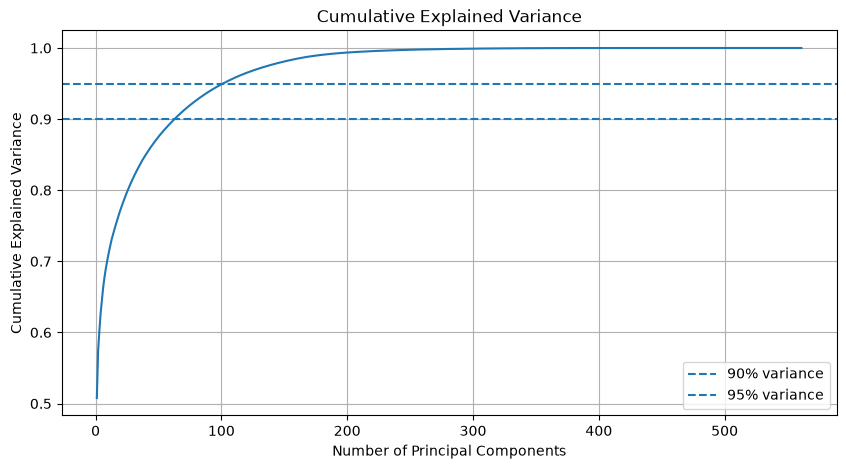

In [18]:
# Plot cumulative explained variance

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(y=0.90, linestyle="--", label="90% variance")
plt.axhline(y=0.95, linestyle="--", label="95% variance")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Determine components required for common variance thresholds

components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components required for 90% variance:", components_90)
print("Components required for 95% variance:", components_95)

Components required for 90% variance: 63
Components required for 95% variance: 102
